In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 

import pandas as pd


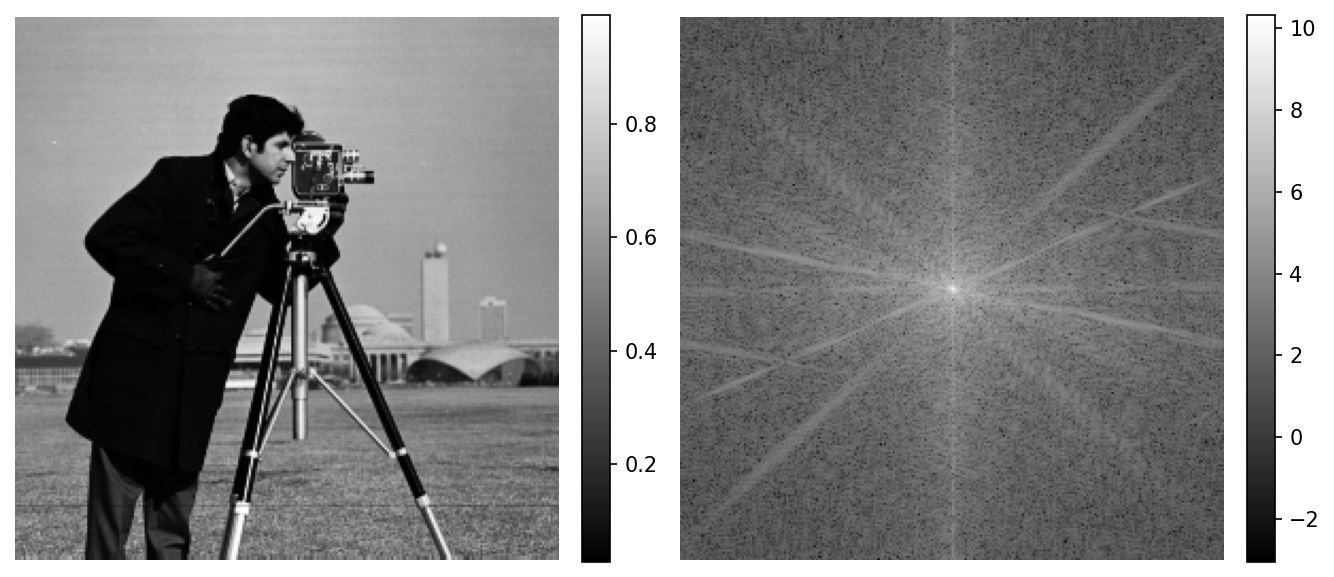

In [4]:
from scipy.fftpack import fft, ifft, fftfreq, fftshift, fft2, ifft2
from matplotlib.image import imread

im_read = imread('figs/cameraman.png', 0)

F6 = np.fft.fft2(im_read)    
LF6s = np.log(np.abs(fftshift(F6)))

fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(np.real(im_read), cmap='gray')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(LF6s, cmap='gray')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
fig.savefig('./figs/T8_2d_6.pdf', dpi=300)

if 0:
    F6_magnitude = np.abs(F6)
    F6_phase = np.angle(F6)

    fig, axs = plt.subplots(1, 2, figsize=(9, 6))
    im = axs[0].imshow(fftshift(F6_magnitude), cmap='gray')
    axs[0].axis('off')
    fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

    im = axs[1].imshow(fftshift(F6_phase), cmap='gray')
    axs[1].axis('off')
    fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
    plt.show()

# Filter the Image 

/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_90982/3523913621.py:13: RuntimeWarning: divide by zero encountered in log
  LF6f = np.log(np.abs(F6s_filtered))


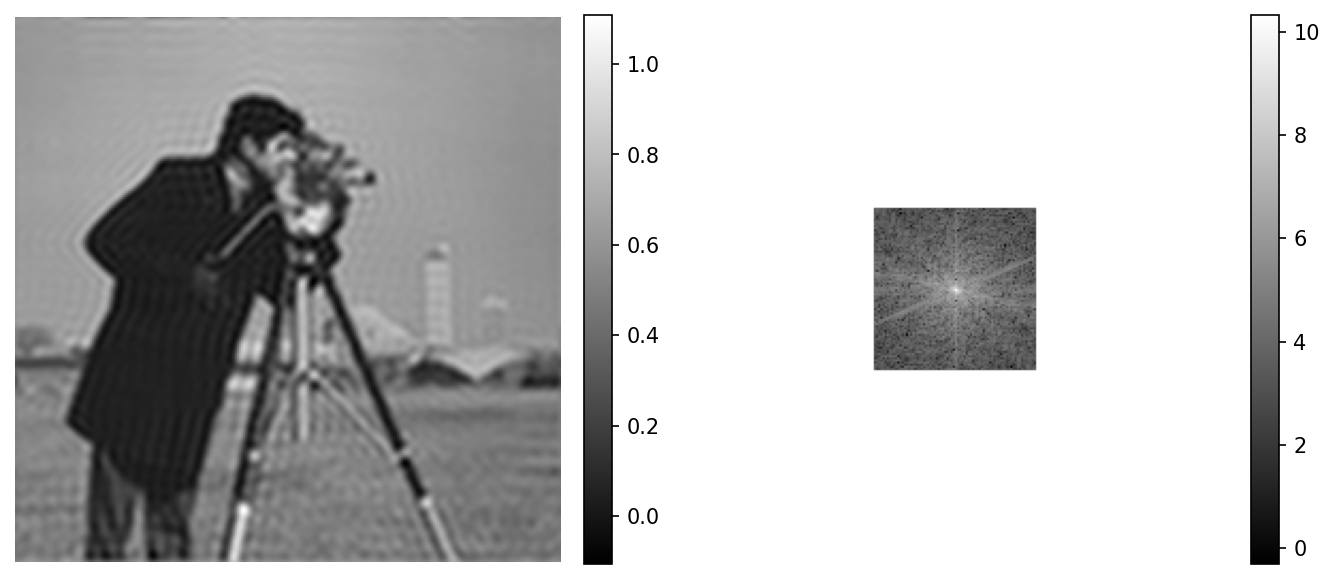

In [5]:
# Define a low-pass filter
def low_pass_filter(F, cutoff):
    rows, cols = F.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.zeros((rows, cols), dtype=np.float32)
    mask[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 1
    return F * mask

# Apply the low-pass filter to F6
Nrows, Ncols = F6.shape
cutoff = int(0.3*Nrows//2)  
F6s_filtered = low_pass_filter(fftshift(F6), cutoff)
LF6f = np.log(np.abs(F6s_filtered))

# Reconstruct the image from the filtered frequency domain
image_filtered = np.fft.ifft2(ifftshift(F6s_filtered))

fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(np.real(image_filtered), cmap='gray')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(LF6f, cmap='gray')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
plt.show()

/var/folders/wv/3mv73kyx13x52f1hzz303m740000gn/T/ipykernel_90982/3886960172.py:13: RuntimeWarning: divide by zero encountered in log
  LF6hp = np.log(np.abs(F6s_hp))


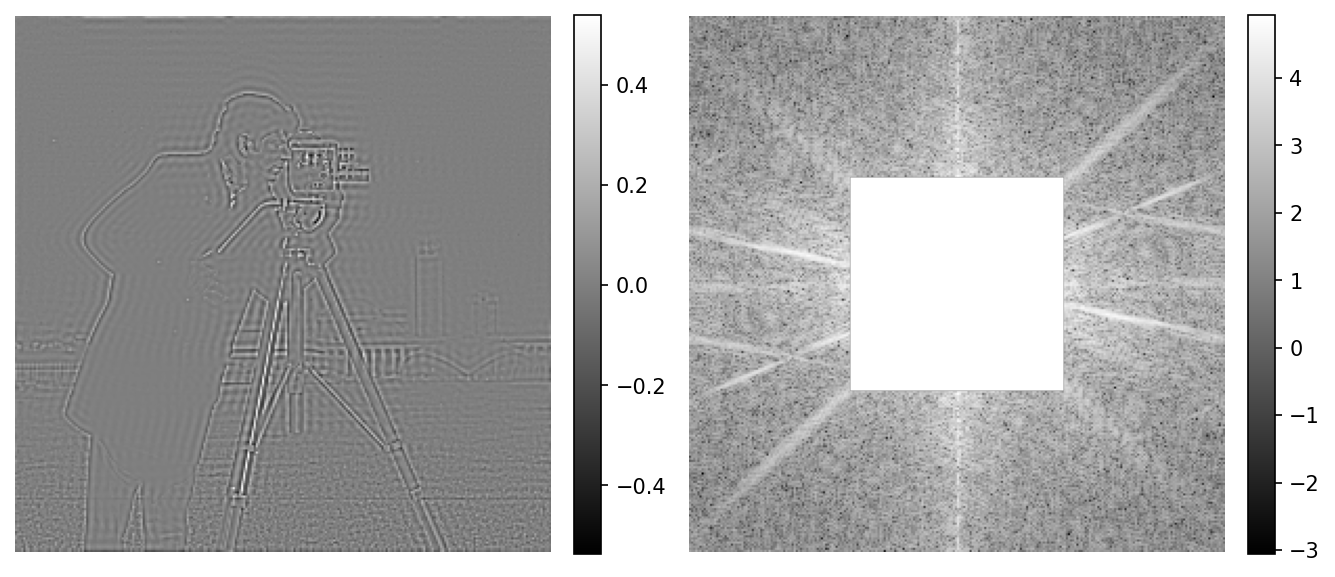

In [6]:
# Define a low-pass filter
def high_pass_filter(F, cutoff):
    rows, cols = F.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), dtype=np.float32)
    mask[crow - cutoff:crow + cutoff, ccol - cutoff:ccol + cutoff] = 0
    return F * mask

# Apply the low-pass filter to F6
Nrows, Ncols = F6.shape
cutoff = int(0.4*Nrows//2)  
F6s_hp = high_pass_filter(fftshift(F6), cutoff)
LF6hp = np.log(np.abs(F6s_hp))

# Reconstruct the image from the filtered frequency domain
image_filtered = np.fft.ifft2(ifftshift(F6s_hp))

fig, axs = plt.subplots(1, 2, figsize=(9, 6))
im = axs[0].imshow(np.real(image_filtered), cmap='gray')
axs[0].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[0])

im = axs[1].imshow(LF6hp, cmap='gray')
axs[1].axis('off')
fig.colorbar(im,fraction=0.046, pad=0.04, ax=axs[1])
plt.show()

# Spatial-domain filtering: 2D convolution (and CNNs)
The frequency-domain masking above has a spatial-domain twin: **convolving** the image with a small **kernel**. A blur kernel is a low-pass filter; a Sobel kernel is a high-pass edge detector. A *convolutional neural network* uses this exact operation but **learns** the kernels from data (and, despite the name, skips the flip — so it's really the correlation of Topic 5).

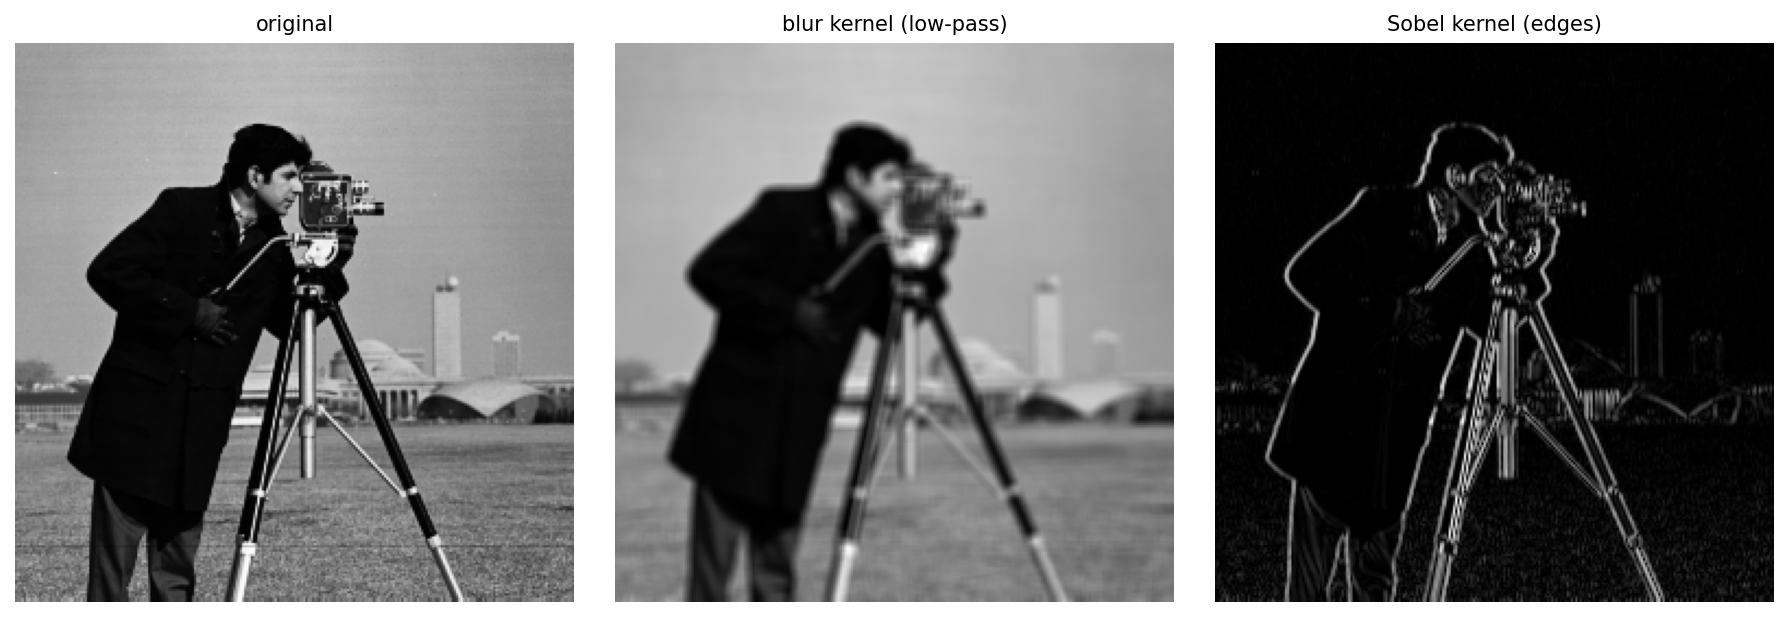

In [7]:
from scipy.signal import convolve2d

# reuse the cameraman image loaded above
img = np.real(im_read).astype(float)
if img.ndim == 3:
    img = img.mean(axis=2)          # collapse to grayscale if RGB
img = img / img.max()

# hand-designed kernels
blur  = np.ones((5, 5)) / 25                              # box blur       -> low-pass
sobel = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])   # vertical edges -> high-pass

out_blur = convolve2d(img, blur,  mode='same', boundary='symm')
out_edge = convolve2d(img, sobel, mode='same', boundary='symm')

fig, ax = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)
for a, im, ttl in zip(ax, [img, out_blur, np.abs(out_edge)],
                      ['original', 'blur kernel (low-pass)', 'Sobel kernel (edges)']):
    a.imshow(im, cmap='gray'); a.set_title(ttl); a.axis('off')
fig.savefig('./figs/T8_conv2d.pdf', bbox_inches='tight', dpi=300)   # save before show
plt.show()